# PCA on Random 40-Row Data

A compact, end-to-end PCA workflow using modular code.

## Overall pipeline

1. Create a small synthetic dataset so we can learn the flow clearly.
2. Separate features and target-like label.
3. Standardize the features because PCA is scale-sensitive.
4. Fit PCA and inspect explained variance plus loadings.
5. Select the number of principal components based on cumulative variance.
6. Use the selected PCs for train/test split and model training.

Why this structure?
- each cell does one job
- helper functions are reusable
- interpretation happens before model training

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Keep the random data reproducible for learning and debugging.
np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")

## 1. Build a small dataset

Keep the data slightly correlated so PCA has something meaningful to compress.

Focus points:
- meaningful feature names
- reproducible randomness
- keep data creation separate from modeling

In [8]:
def create_sample_data(n_rows=40):
    # Build a base signal so some columns stay correlated.
    base = np.random.normal(loc=50, scale=10, size=n_rows)
    noise_small = np.random.normal(loc=0, scale=2, size=n_rows)
    noise_medium = np.random.normal(loc=0, scale=4, size=n_rows)

    data = pd.DataFrame({
        "study_hours": base / 5 + noise_small,
        "practice_score": base + noise_small,
        "mock_score": base * 1.1 + noise_small,
        "attendance": 70 + base / 3 + noise_medium,
        "sleep_hours": 8 + np.random.normal(loc=0, scale=1, size=n_rows),
    })

    # Create a simple label so we can later train a model on PCs.
    data["group"] = np.where(data["practice_score"] > data["practice_score"].median(), "high", "low")
    return data.round(2)

df = create_sample_data()
feature_cols = ["study_hours", "practice_score", "mock_score", "attendance", "sleep_hours"]

# Inspect the raw sample before preprocessing.
df.head()

,study_hours,practice_score,mock_score,attendance,sleep_hours,group
0,12.47,56.44,61.94,87.44,8.79,high
1,10.07,48.96,53.82,87.63,7.09,high
2,11.06,56.25,61.89,94.74,9.40,high
3,12.44,64.63,71.15,89.67,6.60,high
4,6.57,44.70,49.47,82.65,8.59,low


## 2. Write reusable PCA helpers

Good modular code keeps each step single-purpose.

Focus points:
- separate preprocessing from PCA
- return clean tables, not raw arrays only
- keep function inputs explicit

In [9]:
def scale_features(dataframe, columns):
    # Standardization gives every feature equal importance before PCA.
    scaler = StandardScaler()
    scaled_values = scaler.fit_transform(dataframe[columns])
    scaled_df = pd.DataFrame(scaled_values, columns=columns)
    return scaled_df, scaler


def run_pca(scaled_df, n_components=None):
    # Fit PCA on already scaled numeric features.
    pca = PCA(n_components=n_components)
    transformed = pca.fit_transform(scaled_df)

    component_names = [f"PC{i}" for i in range(1, transformed.shape[1] + 1)]
    transformed_df = pd.DataFrame(transformed, columns=component_names)

    explained_df = pd.DataFrame({
        "principal_component": component_names,
        "explained_variance_ratio": pca.explained_variance_ratio_,
        "cumulative_variance": np.cumsum(pca.explained_variance_ratio_),
    })

    loadings_df = pd.DataFrame(
        pca.components_.T,
        index=scaled_df.columns,
        columns=component_names,
    )

    return pca, transformed_df, explained_df, loadings_df


def choose_number_of_pcs(explained_df, threshold=0.85):
    # Pick the smallest k such that cumulative variance crosses the threshold.
    selected_count = int((explained_df["cumulative_variance"] < threshold).sum() + 1)
    return selected_count


def train_model_on_pcs(pc_dataframe, labels, test_size=0.25, random_state=42):
    # Split after PCA so the modeling step uses only the selected components.
    X_train, X_test, y_train, y_test = train_test_split(
        pc_dataframe, labels, test_size=test_size, random_state=random_state, stratify=labels
    )

    model = LogisticRegression()
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    metrics = {
        "accuracy": accuracy_score(y_test, predictions),
        "report": classification_report(y_test, predictions),
    }
    return model, metrics

## 3. Run PCA and inspect outputs

PCA should usually be applied after scaling when features have different units.

What to read here:
- explained variance ratio
- cumulative variance
- feature loadings

Why do this before modeling?
- we first confirm how much information each PC keeps
- we avoid blindly choosing components

In [10]:
# Step 1: scale the original numeric features.
scaled_df, scaler = scale_features(df, feature_cols)

# Step 2: run PCA on the scaled matrix.
pca, pca_df, explained_df, loadings_df = run_pca(scaled_df)

# Step 3: keep the minimum number of PCs that capture at least 85% variance.
selected_pc_count = choose_number_of_pcs(explained_df, threshold=0.85)
selected_pc_cols = [f"PC{i}" for i in range(1, selected_pc_count + 1)]

# Step 4: prepare a compact result table for interpretation.
result_df = pd.concat([df[["group"]].reset_index(drop=True), pca_df[selected_pc_cols]], axis=1)

print("Shape of original data:", df[feature_cols].shape)
print("Selected PCs:", selected_pc_cols)
display(explained_df.round(4))
display(loadings_df.round(4))
result_df.head()

Shape of original data: (40, 5)
Selected PCs: ['PC1', 'PC2']


,principal_component,explained_variance_ratio,cumulative_variance
0,PC1,0.6447,0.6447
1,PC2,0.2056,0.8503
2,PC3,0.0994,0.9496
3,PC4,0.0504,1.0000
4,PC5,0.0000,1.0000


,PC1,PC2,PC3,PC4,PC5
study_hours,0.4723,0.0720,-0.5768,0.6623,-0.0208
practice_score,0.5419,0.0642,-0.0696,-0.4316,0.7149
mock_score,0.5403,0.0635,-0.0541,-0.4612,-0.6989
attendance,0.4372,-0.1940,0.7852,0.3933,0.0000
sleep_hours,-0.0188,0.9742,0.2072,0.0879,-0.0000


,group,PC1,PC2
0,high,1.707322,0.973830
1,high,0.421572,-0.918728
2,high,2.095156,1.238662
3,high,2.922578,-1.209859
4,low,-1.239465,0.638349


## 4. Why select these PCs?

We selected the smallest number of PCs whose cumulative variance reached at least 85%.

In this notebook, that means keeping the first 2 PCs because:
- PC1 captures the largest direction of variation
- PC2 adds the next most useful independent information
- PC1 + PC2 together already preserve most of the dataset structure

Rule of thumb:
- use fewer PCs when you want simpler models
- use more PCs when the variance retained is still too low

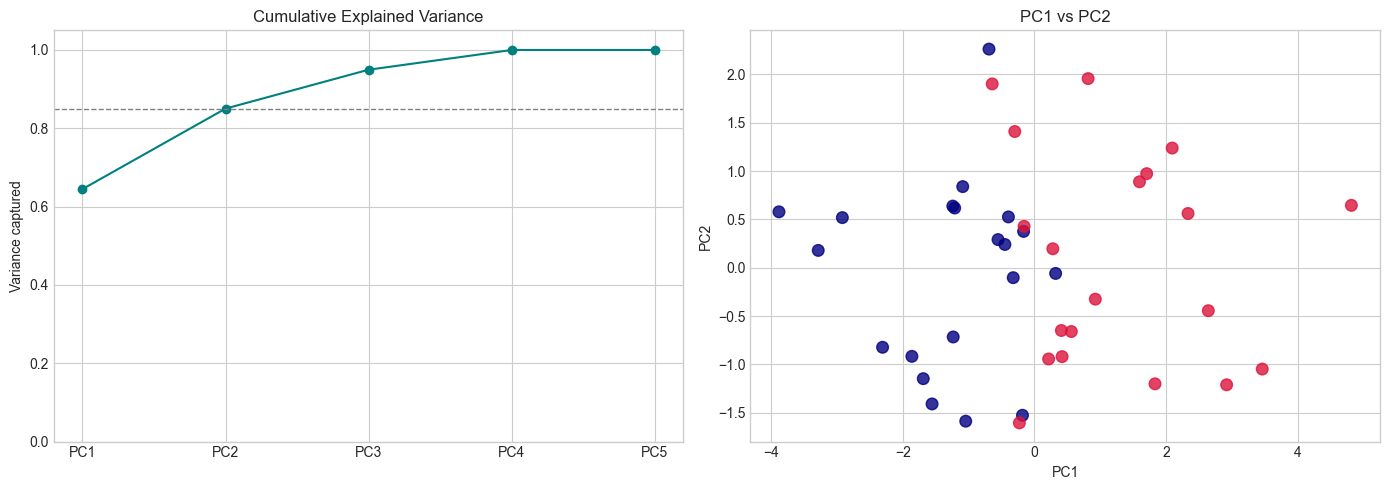

In [11]:
# Visualize how fast variance accumulates across PCs.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    explained_df["principal_component"],
    explained_df["cumulative_variance"],
    marker="o",
    color="teal",
)
axes[0].axhline(0.85, color="gray", linestyle="--", linewidth=1)
axes[0].set_title("Cumulative Explained Variance")
axes[0].set_ylabel("Variance captured")
axes[0].set_ylim(0, 1.05)

# Plot the first two retained PCs to inspect separation visually.
colors = result_df["group"].map({"high": "crimson", "low": "navy"})
axes[1].scatter(result_df["PC1"], result_df["PC2"], c=colors, s=70, alpha=0.8)
axes[1].set_title("PC1 vs PC2")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()

## 5. Proceed further: train/test split and model training

After choosing the PCs, use them as your new feature set for modeling.

Why split the data?
- training data teaches the model
- test data checks whether the model generalizes

Why train on PCs instead of raw features?
- fewer input columns
- less redundancy from correlated features
- simpler feature space for some models

In [15]:
# Use only the selected principal components as model inputs.
X_pca = pca_df[selected_pc_cols]
y = df["group"]

# print(X_pca)
# print(y)

# Train a simple classifier on the PCA-transformed features.
model, metrics = train_model_on_pcs(X_pca, y)

print(f"Accuracy using {selected_pc_count} PCs: {metrics['accuracy']:.3f}")
print(metrics["report"])

Accuracy using 2 PCs: 0.600
              precision    recall  f1-score   support

        high       0.60      0.60      0.60         5
         low       0.60      0.60      0.60         5

    accuracy                           0.60        10
   macro avg       0.60      0.60      0.60        10
weighted avg       0.60      0.60      0.60        10



## 6. What to focus on in modular PCA code

Keep these habits:
- one function for one job
- clear names for features and outputs
- scale before PCA when units differ
- inspect both variance and loadings
- choose PCs using a defined threshold, not guessing
- keep plotting and training separate from preprocessing logic

This makes the full pipeline easier to debug, teach, and reuse on real datasets.